## 1) Problem Identification

## 2) Business Analysis

## 3) Objectives

## 4) Dataset Information

## 5) Technologies Used

## 6) Project Workflow

### 1) Import Libraries

In [69]:
# Basics
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Model Selection
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler, LabelEncoder
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

### 2) Data Collection

In [2]:
flight_cost = pd.read_excel('C:/Users/Admin/Documents/GitHub/flight-ticket-price-prediction-linear-regression/Dataset/Flight_Fare.xlsx')
flight_cost

,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price
0,IndiGo,24/03/2019,Banglore,New Delhi,BLR → DEL,22:20,01:10 22 Mar,2h 50m,non-stop,No info,3897
1,Air India,1/05/2019,Kolkata,Banglore,CCU → IXR → BBI → BLR,05:50,13:15,7h 25m,2 stops,No info,7662
2,Jet Airways,9/06/2019,Delhi,Cochin,DEL → LKO → BOM → COK,09:25,04:25 10 Jun,19h,2 stops,No info,13882
3,IndiGo,12/05/2019,Kolkata,Banglore,CCU → NAG → BLR,18:05,23:30,5h 25m,1 stop,No info,6218
4,IndiGo,01/03/2019,Banglore,New Delhi,BLR → NAG → DEL,16:50,21:35,4h 45m,1 stop,No info,13302
...,...,...,...,...,...,...,...,...,...,...,...
10678,Air Asia,9/04/2019,Kolkata,Banglore,CCU → BLR,19:55,22:25,2h 30m,non-stop,No info,4107
10679,Air India,27/04/2019,Kolkata,Banglore,CCU → BLR,20:45,23:20,2h 35m,non-stop,No info,4145
10680,Jet Airways,27/04/2019,Banglore,Delhi,BLR → DEL,08:20,11:20,3h,non-stop,No info,7229
10681,Vistara,01/03/2019,Banglore,New Delhi,BLR → DEL,11:30,14:10,2h 40m,non-stop,No info,12648


### 3) Data Understanding

In [3]:
flight_cost.head()

,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price
0,IndiGo,24/03/2019,Banglore,New Delhi,BLR → DEL,22:20,01:10 22 Mar,2h 50m,non-stop,No info,3897
1,Air India,1/05/2019,Kolkata,Banglore,CCU → IXR → BBI → BLR,05:50,13:15,7h 25m,2 stops,No info,7662
2,Jet Airways,9/06/2019,Delhi,Cochin,DEL → LKO → BOM → COK,09:25,04:25 10 Jun,19h,2 stops,No info,13882
3,IndiGo,12/05/2019,Kolkata,Banglore,CCU → NAG → BLR,18:05,23:30,5h 25m,1 stop,No info,6218
4,IndiGo,01/03/2019,Banglore,New Delhi,BLR → NAG → DEL,16:50,21:35,4h 45m,1 stop,No info,13302


In [4]:
flight_cost.tail()

,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price
10678,Air Asia,9/04/2019,Kolkata,Banglore,CCU → BLR,19:55,22:25,2h 30m,non-stop,No info,4107
10679,Air India,27/04/2019,Kolkata,Banglore,CCU → BLR,20:45,23:20,2h 35m,non-stop,No info,4145
10680,Jet Airways,27/04/2019,Banglore,Delhi,BLR → DEL,08:20,11:20,3h,non-stop,No info,7229
10681,Vistara,01/03/2019,Banglore,New Delhi,BLR → DEL,11:30,14:10,2h 40m,non-stop,No info,12648
10682,Air India,9/05/2019,Delhi,Cochin,DEL → GOI → BOM → COK,10:55,19:15,8h 20m,2 stops,No info,11753


In [5]:
flight_cost.columns

Index(['Airline', 'Date_of_Journey', 'Source', 'Destination', 'Route',
       'Dep_Time', 'Arrival_Time', 'Duration', 'Total_Stops',
       'Additional_Info', 'Price'],
      dtype='object')

### 4) Exploratory Data Analysis (EDA)

#### 1) Dataset Shape

In [6]:
flight_cost.shape

(10683, 11)

#### 2) Data Type

In [7]:
flight_cost.dtypes

Airline            object
Date_of_Journey    object
Source             object
Destination        object
Route              object
Dep_Time           object
Arrival_Time       object
Duration           object
Total_Stops        object
Additional_Info    object
Price               int64
dtype: object

#### 3) Missing Values

In [8]:
flight_cost.isnull().sum()

Airline            0
Date_of_Journey    0
Source             0
Destination        0
Route              1
Dep_Time           0
Arrival_Time       0
Duration           0
Total_Stops        1
Additional_Info    0
Price              0
dtype: int64

##### Observation

#### 4) Duplicates

In [9]:
flight_cost.duplicated().sum()

np.int64(220)

##### Observation

#### 5) Statistical Summary

In [10]:
flight_cost.describe()

,Price
count,10683.000000
mean,9087.064121
std,4611.359167
min,1759.000000
25%,5277.000000
50%,8372.000000
75%,12373.000000
max,79512.000000


#### 6) Correlation Analysis

In [11]:
corr_analysis = flight_cost.corr(numeric_only=True)
corr_analysis

,Price
Price,1.0


#### 7) Class Distibution

In [12]:
flight_cost.columns

Index(['Airline', 'Date_of_Journey', 'Source', 'Destination', 'Route',
       'Dep_Time', 'Arrival_Time', 'Duration', 'Total_Stops',
       'Additional_Info', 'Price'],
      dtype='object')

In [13]:
flight_cost['Airline'].value_counts()

Airline
Jet Airways                          3849
IndiGo                               2053
Air India                            1752
Multiple carriers                    1196
SpiceJet                              818
Vistara                               479
Air Asia                              319
GoAir                                 194
Multiple carriers Premium economy      13
Jet Airways Business                    6
Vistara Premium economy                 3
Trujet                                  1
Name: count, dtype: int64

In [14]:
flight_cost['Source'].value_counts()

Source
Delhi       4537
Kolkata     2871
Banglore    2197
Mumbai       697
Chennai      381
Name: count, dtype: int64

In [15]:
flight_cost['Destination'].value_counts()

Destination
Cochin       4537
Banglore     2871
Delhi        1265
New Delhi     932
Hyderabad     697
Kolkata       381
Name: count, dtype: int64

In [16]:
flight_cost['Total_Stops'].value_counts()

Total_Stops
1 stop      5625
non-stop    3491
2 stops     1520
3 stops       45
4 stops        1
Name: count, dtype: int64

In [17]:
flight_cost['Additional_Info'].value_counts()

Additional_Info
No info                         8345
In-flight meal not included     1982
No check-in baggage included     320
1 Long layover                    19
Change airports                    7
Business class                     4
No Info                            3
1 Short layover                    1
Red-eye flight                     1
2 Long layover                     1
Name: count, dtype: int64

#### 8) Outliers Detection

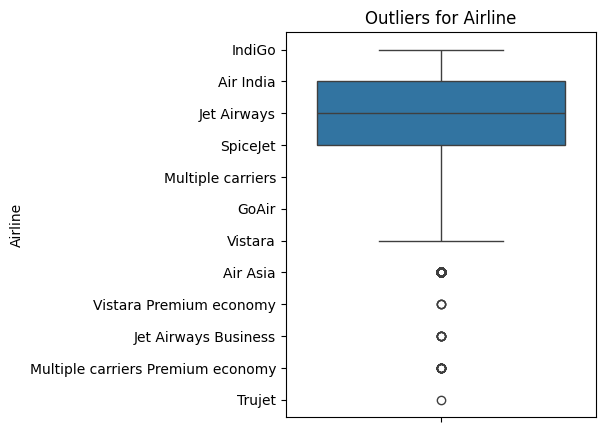

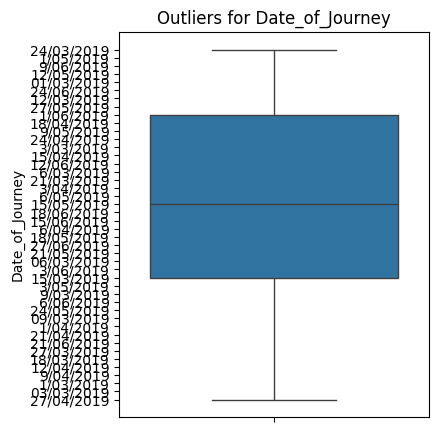

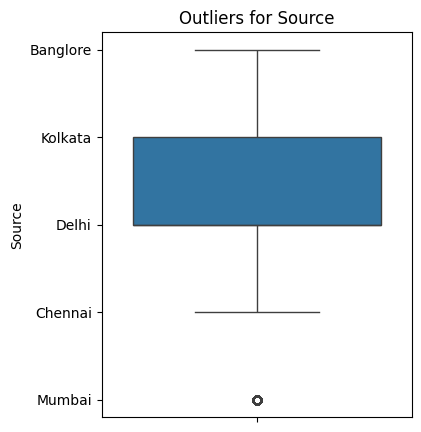

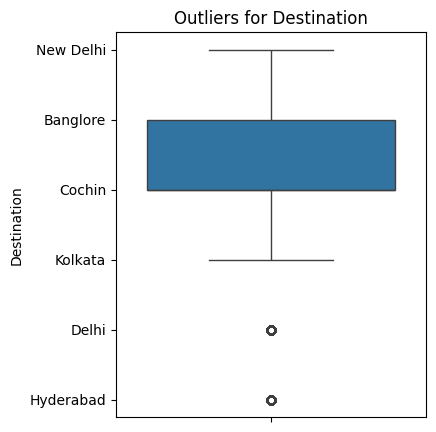

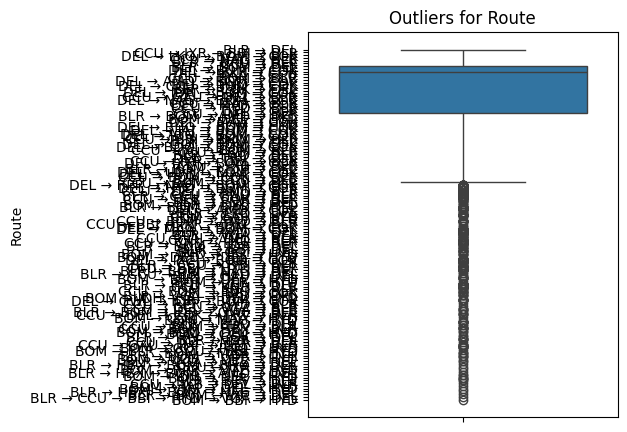

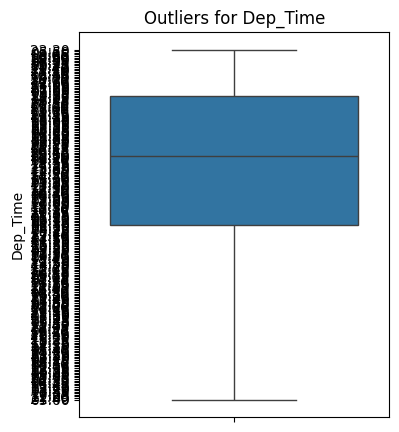

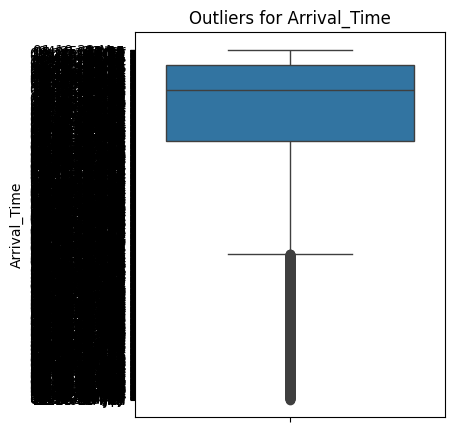

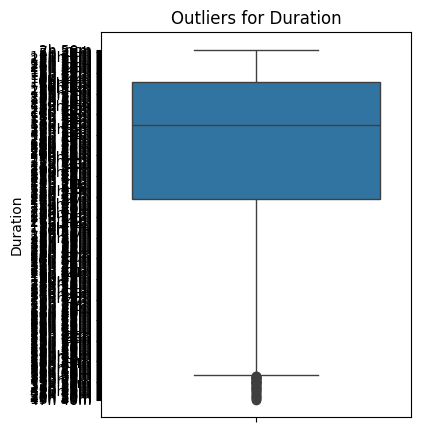

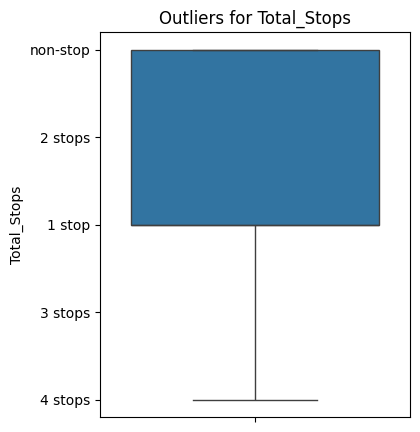

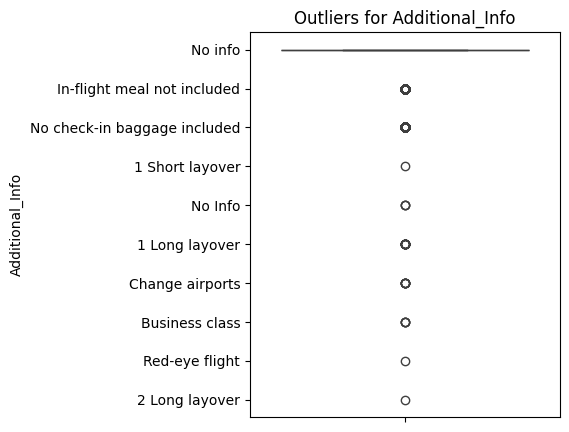

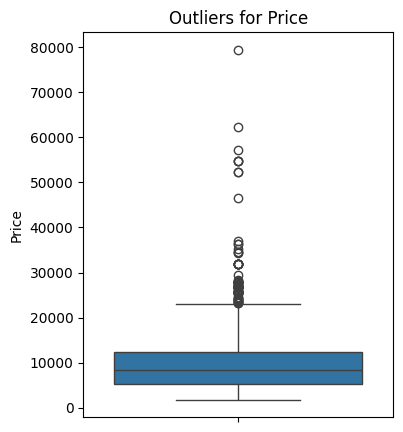

In [18]:
columns = flight_cost.columns

for out_columns in columns:
    plt.figure(figsize=(4,5))

    sns.boxplot(y=flight_cost[out_columns])

    plt.title(f'Outliers for {out_columns}')

    plt.show()

##### Observation

#### 9) Feature Distribution

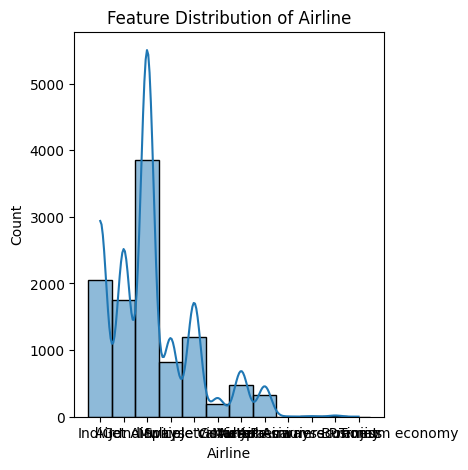

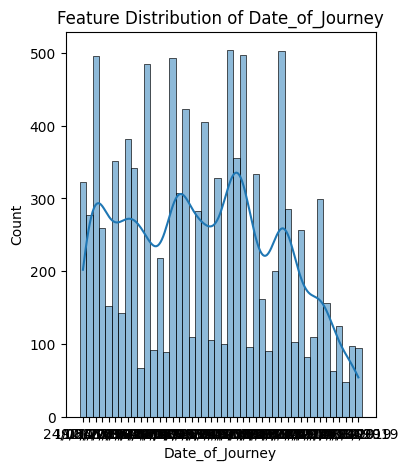

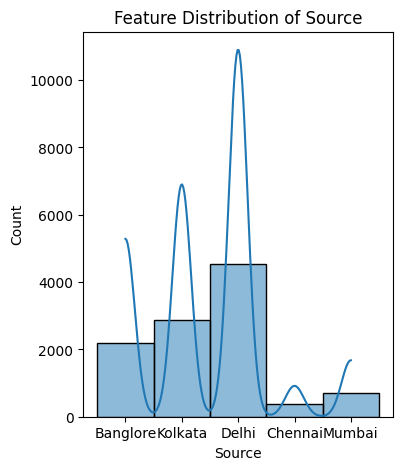

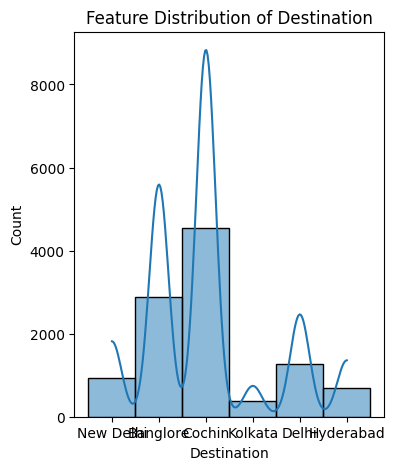

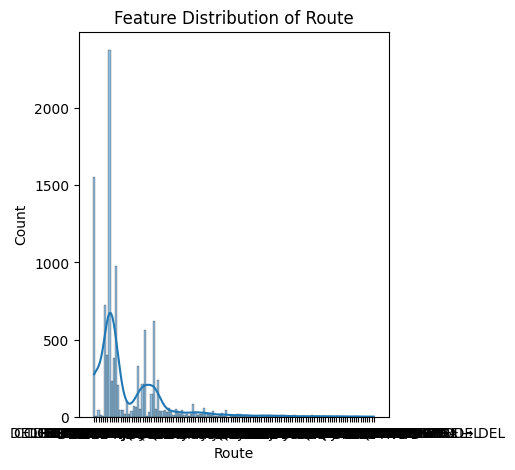

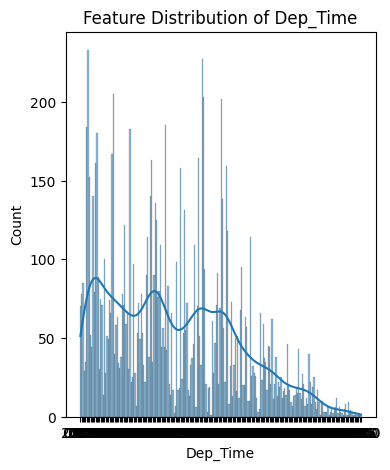

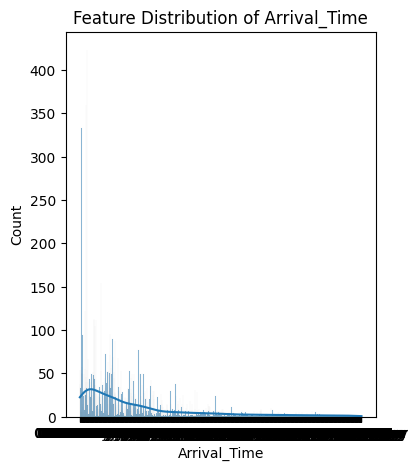

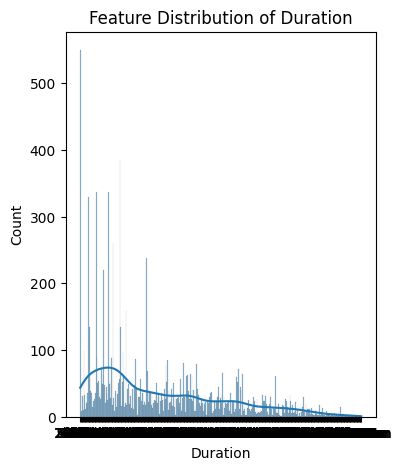

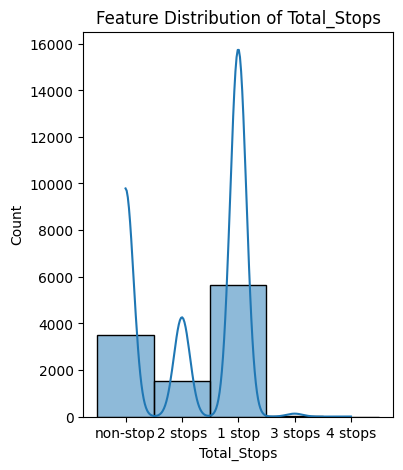

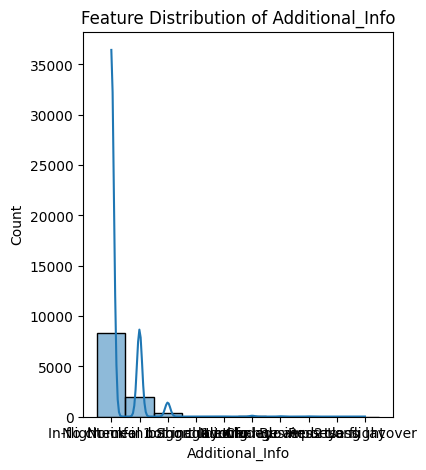

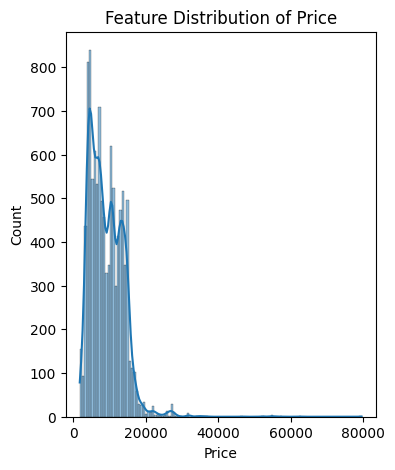

In [19]:
column = flight_cost.columns

for fea_cols in column:
    plt.figure(figsize=(4,5))

    sns.histplot(data=flight_cost[fea_cols], kde=True)
    plt.title(f'Feature Distribution of {fea_cols}')

    plt.show()

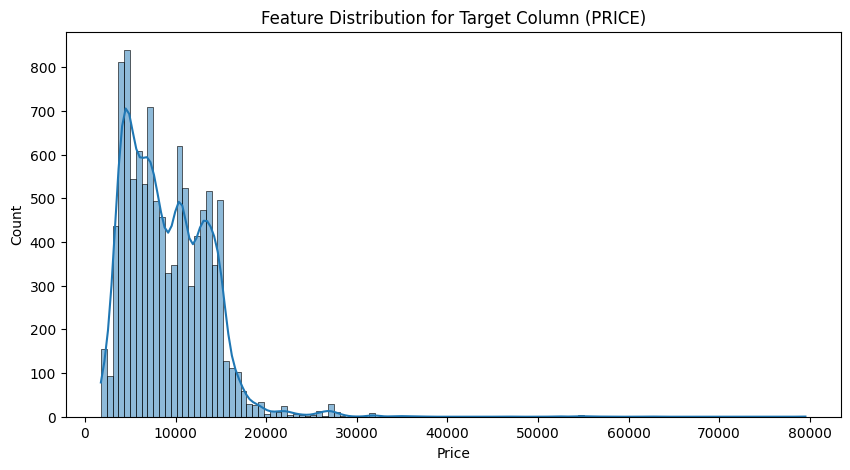

In [20]:
# Target Column
plt.figure(figsize=(10,5))

sns.histplot(x=flight_cost['Price'], kde=True)
plt.title('Feature Distribution for Target Column (PRICE)')

plt.show()

#### Bi-Variant Analysis

In [21]:
flight_cost.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10683 entries, 0 to 10682
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Airline          10683 non-null  object
 1   Date_of_Journey  10683 non-null  object
 2   Source           10683 non-null  object
 3   Destination      10683 non-null  object
 4   Route            10682 non-null  object
 5   Dep_Time         10683 non-null  object
 6   Arrival_Time     10683 non-null  object
 7   Duration         10683 non-null  object
 8   Total_Stops      10682 non-null  object
 9   Additional_Info  10683 non-null  object
 10  Price            10683 non-null  int64 
dtypes: int64(1), object(10)
memory usage: 918.2+ KB


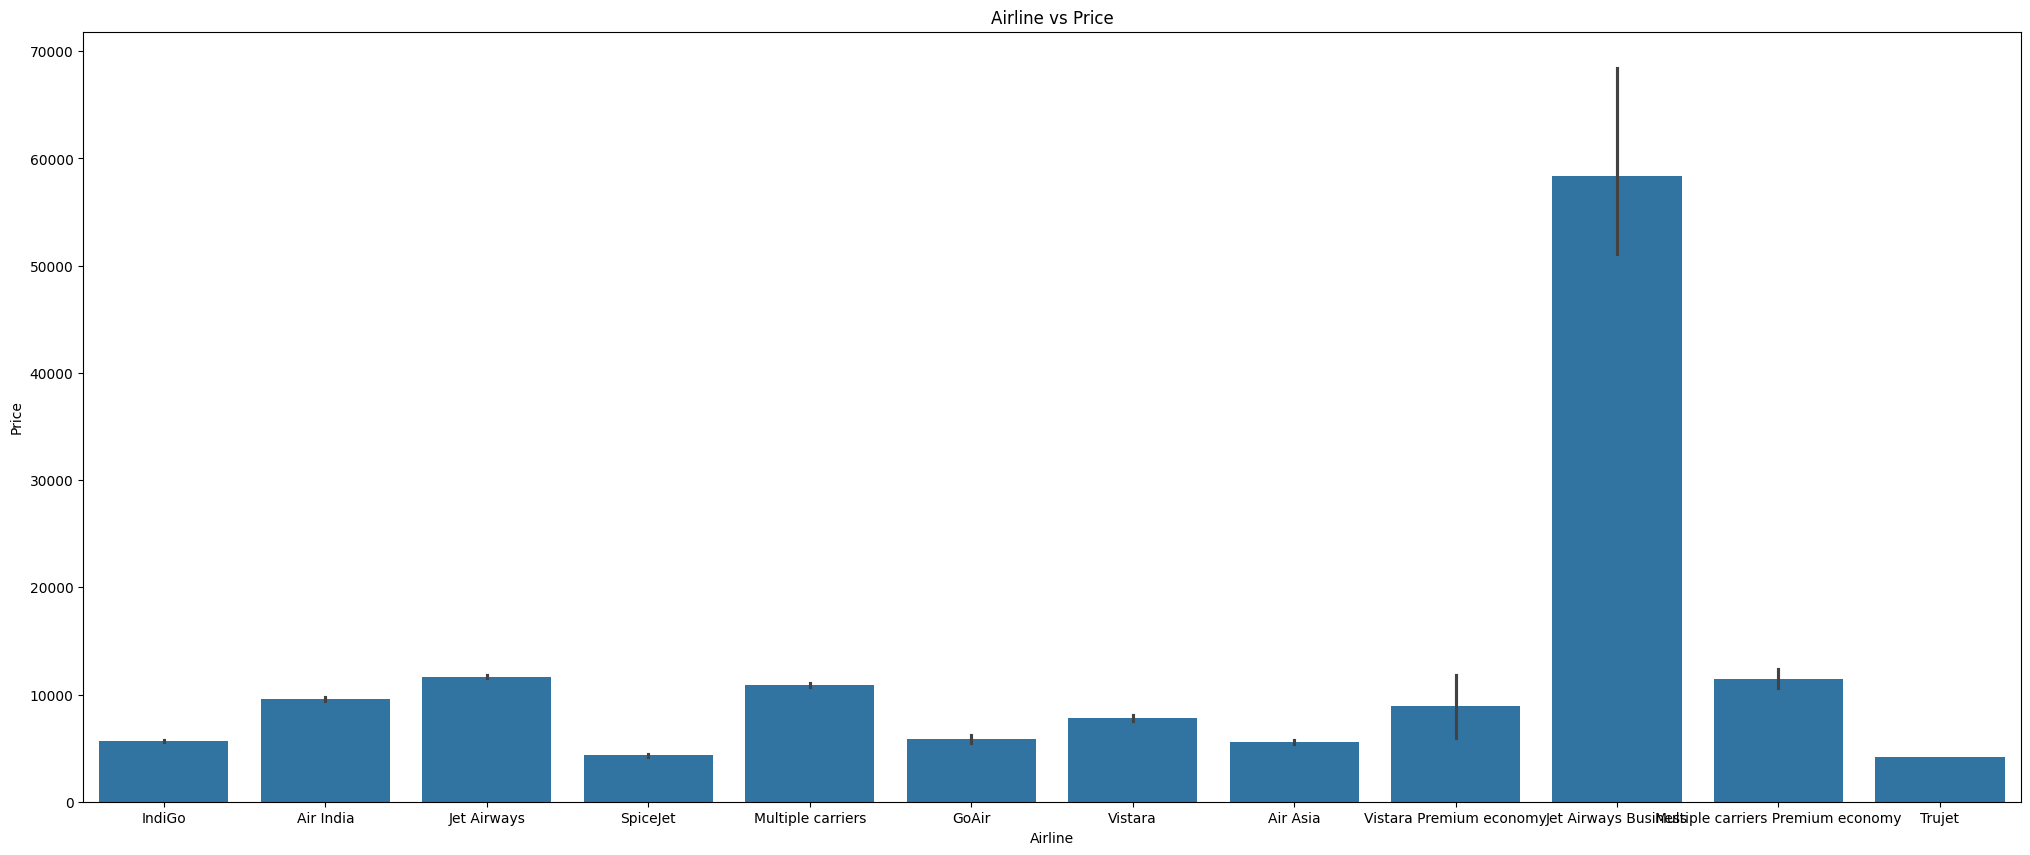

In [22]:
# Airline vs Price (C vs N)

plt.figure(figsize=(25,10))

sns.barplot(x='Airline',
            y='Price',
            data=flight_cost
           )
plt.title('Airline vs Price')

plt.show()

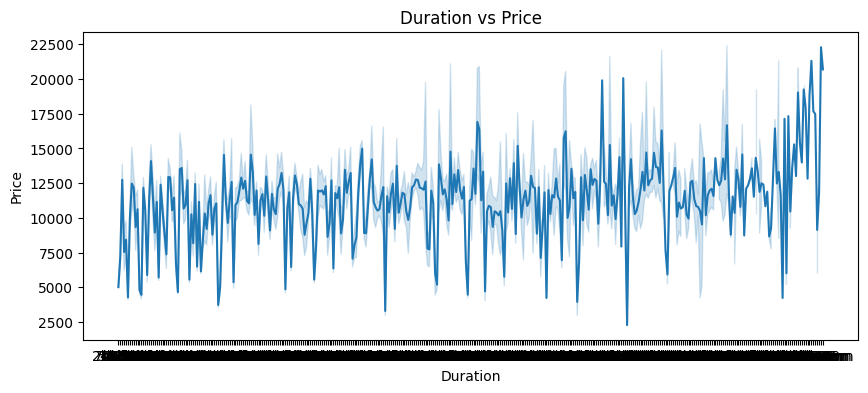

In [23]:
# Duration vs Price (C vs N)

plt.figure(figsize=(10,4))

sns.lineplot(x='Duration',
            y='Price',
            data=flight_cost
           )
plt.title('Duration vs Price')

plt.show()

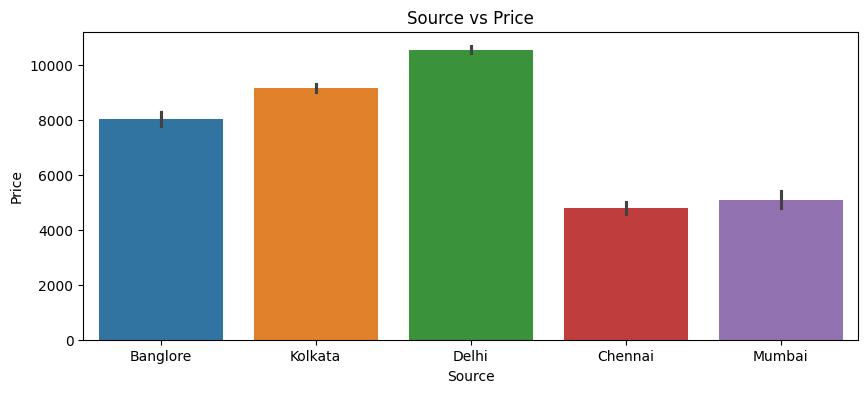

In [24]:
# Source vs Price (C vs N)

plt.figure(figsize=(10,4))

sns.barplot(x='Source', 
            y='Price', 
            hue='Source',
            data=flight_cost
           )

plt.title('Source vs Price')

plt.show()

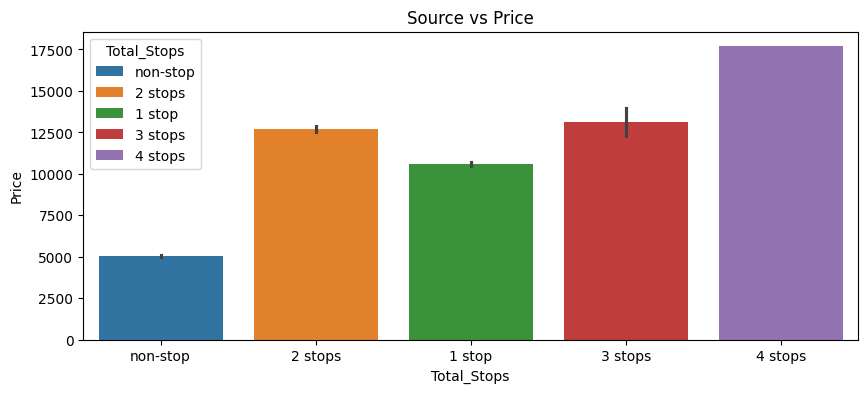

In [25]:
# Total_Stops vs Price (C vs N)

plt.figure(figsize=(10,4))

sns.barplot(x='Total_Stops',
            y='Price',
            hue='Total_Stops',
            data=flight_cost,
           )

plt.title('Source vs Price')

plt.show()

#### Multi-Variant Analysis

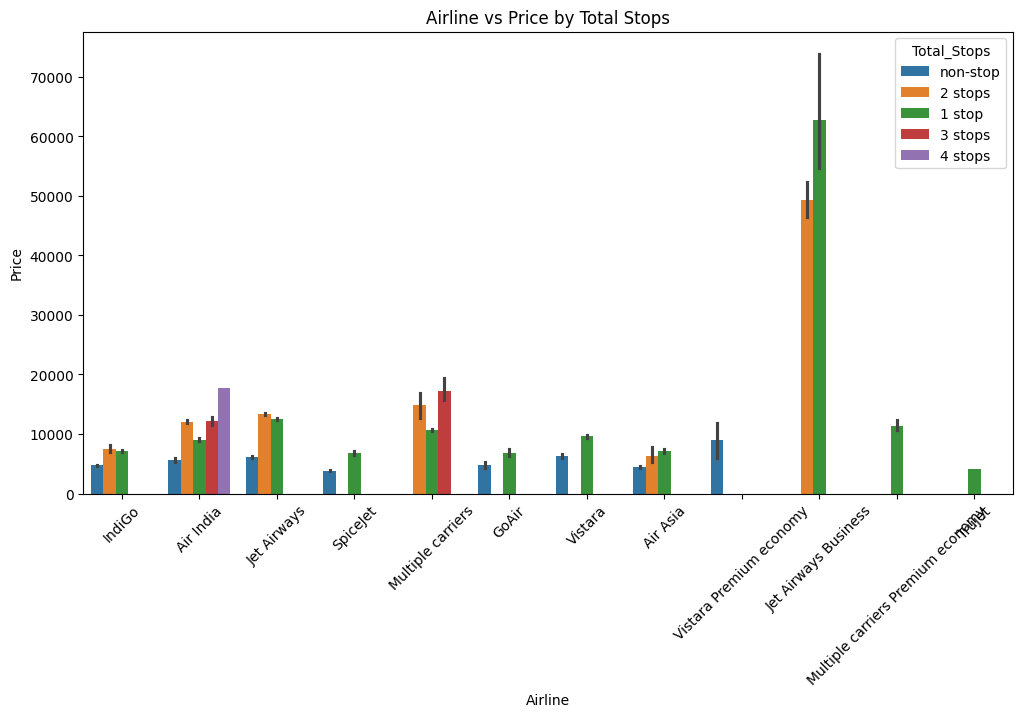

In [26]:
plt.figure(figsize=(12,6))

sns.barplot(x='Airline',
            y='Price',
            hue='Total_Stops',
            data=flight_cost)

plt.xticks(rotation=45)
plt.title("Airline vs Price by Total Stops")
plt.show() 

### 5) Data Cleaning

#### 1) Handling Duplicates

In [27]:
flight_cost = flight_cost.drop_duplicates()

In [28]:
flight_cost.duplicated().sum() 

np.int64(0)

#### 2) Handling Missing Values

In [29]:
columns = ['Route','Total_Stops']

for mis_cols in columns:
    flight_cost[mis_cols] = flight_cost[mis_cols].fillna(flight_cost[mis_cols].mode()[0])

C:\Users\Admin\AppData\Local\Temp\ipykernel_25544\3260627949.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  flight_cost[mis_cols] = flight_cost[mis_cols].fillna(flight_cost[mis_cols].mode()[0])


In [30]:
flight_cost.isnull().sum()

Airline            0
Date_of_Journey    0
Source             0
Destination        0
Route              0
Dep_Time           0
Arrival_Time       0
Duration           0
Total_Stops        0
Additional_Info    0
Price              0
dtype: int64

#### 3) Handling Outlier

In [32]:
feature_cols = 'Price'
Q1 = flight_cost[feature_cols].quantile(0.25)
Q3 = flight_cost[feature_cols].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

flight_cost[feature_cols] = flight_cost[feature_cols].clip(lower=lower, upper=upper)

C:\Users\Admin\AppData\Local\Temp\ipykernel_25544\4231614989.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  flight_cost[feature_cols] = flight_cost[feature_cols].clip(lower=lower, upper=upper)


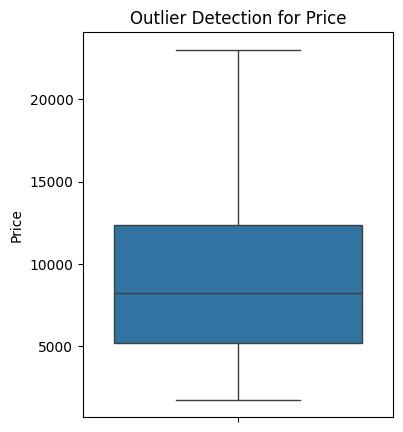

In [33]:
plt.figure(figsize=(4,5))

sns.boxplot(flight_cost['Price'])

plt.title('Outlier Detection for Price')

plt.show()

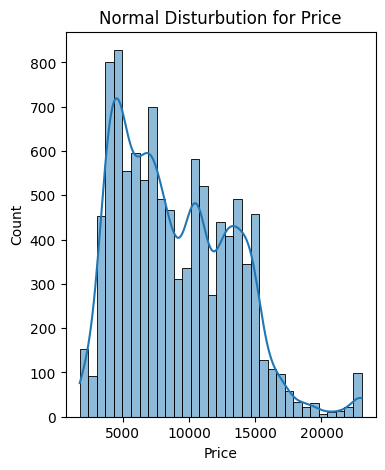

In [34]:
plt.figure(figsize=(4,5))

sns.histplot(flight_cost['Price'], kde=True)

plt.title("Normal Disturbution for Price")

plt.show()

### 6) Feature Engineering

In [35]:
flight_cost.head(2)

,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price
0,IndiGo,24/03/2019,Banglore,New Delhi,BLR → DEL,22:20,01:10 22 Mar,2h 50m,non-stop,No info,3897.0
1,Air India,1/05/2019,Kolkata,Banglore,CCU → IXR → BBI → BLR,05:50,13:15,7h 25m,2 stops,No info,7662.0


In [36]:
flight_cost.columns

Index(['Airline', 'Date_of_Journey', 'Source', 'Destination', 'Route',
       'Dep_Time', 'Arrival_Time', 'Duration', 'Total_Stops',
       'Additional_Info', 'Price'],
      dtype='object')

#### 1) Convert Date of Journey, Dep Time, Arrival Time and Duration

##### Convert Date_of_Journey

In [37]:
flight_cost['Date_of_Journey'] = pd.to_datetime(
    flight_cost['Date_of_Journey'],
    format='%d/%m/%Y'
)

flight_cost['Journey_Day'] = flight_cost['Date_of_Journey'].dt.day
flight_cost['Journey_Month'] = flight_cost['Date_of_Journey'].dt.month

# Drop original column
flight_cost.drop('Date_of_Journey', axis=1, inplace=True) 

C:\Users\Admin\AppData\Local\Temp\ipykernel_25544\2488718469.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  flight_cost['Date_of_Journey'] = pd.to_datetime(
C:\Users\Admin\AppData\Local\Temp\ipykernel_25544\2488718469.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  flight_cost['Journey_Day'] = flight_cost['Date_of_Journey'].dt.day
C:\Users\Admin\AppData\Local\Temp\ipykernel_25544\2488718469.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .

##### Convert Dep_Time

In [38]:
flight_cost['Dep_Time'] = pd.to_datetime(flight_cost['Dep_Time'])

flight_cost['Dep_Hour'] = flight_cost['Dep_Time'].dt.hour
flight_cost['Dep_Minute'] = flight_cost['Dep_Time'].dt.minute

# Drop original column
flight_cost.drop('Dep_Time', axis=1, inplace=True) 

C:\Users\Admin\AppData\Local\Temp\ipykernel_25544\954046247.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  flight_cost['Dep_Time'] = pd.to_datetime(flight_cost['Dep_Time'])
C:\Users\Admin\AppData\Local\Temp\ipykernel_25544\954046247.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  flight_cost['Dep_Time'] = pd.to_datetime(flight_cost['Dep_Time'])
C:\Users\Admin\AppData\Local\Temp\ipykernel_25544\954046247.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https:/

##### Convert Arrival_Time

In [39]:
flight_cost['Arrival_Time'] = pd.to_datetime(flight_cost['Arrival_Time'])

flight_cost['Arrival_Hour'] = flight_cost['Arrival_Time'].dt.hour
flight_cost['Arrival_Minute'] = flight_cost['Arrival_Time'].dt.minute

# Drop original column
flight_cost.drop('Arrival_Time', axis=1, inplace=True)

C:\Users\Admin\AppData\Local\Temp\ipykernel_25544\1007176255.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  flight_cost['Arrival_Time'] = pd.to_datetime(flight_cost['Arrival_Time'])
C:\Users\Admin\AppData\Local\Temp\ipykernel_25544\1007176255.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  flight_cost['Arrival_Time'] = pd.to_datetime(flight_cost['Arrival_Time'])
C:\Users\Admin\AppData\Local\Temp\ipykernel_25544\1007176255.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the doc

##### Convert Duration to Minutes

In [40]:
def convert_duration(duration):
    hours = 0
    minutes = 0

    if 'h' in duration:
        hours = int(duration.split('h')[0])

    if 'm' in duration:
        minutes = int(duration.split('m')[0].split()[-1])

    return hours * 60 + minutes


flight_cost['Duration'] = flight_cost['Duration'].apply(convert_duration) 

C:\Users\Admin\AppData\Local\Temp\ipykernel_25544\3431413971.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  flight_cost['Duration'] = flight_cost['Duration'].apply(convert_duration)


In [42]:
flight_cost.head(2)

,Airline,Source,Destination,Route,Duration,Total_Stops,Additional_Info,Price,Journey_Day,Journey_Month,Dep_Hour,Dep_Minute,Arrival_Hour,Arrival_Minute
0,IndiGo,Banglore,New Delhi,BLR → DEL,170,non-stop,No info,3897.0,24,3,22,20,1,10
1,Air India,Kolkata,Banglore,CCU → IXR → BBI → BLR,445,2 stops,No info,7662.0,1,5,5,50,13,15


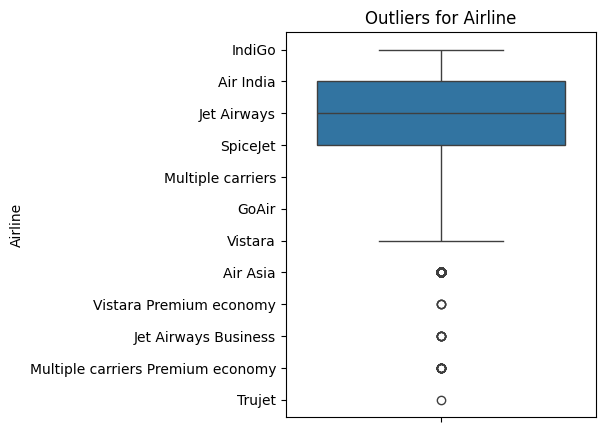

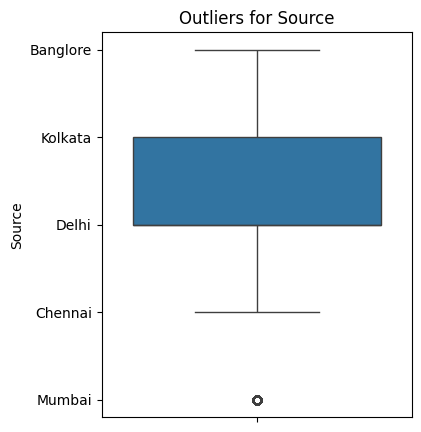

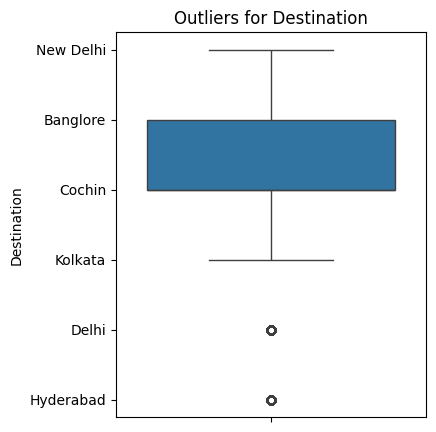

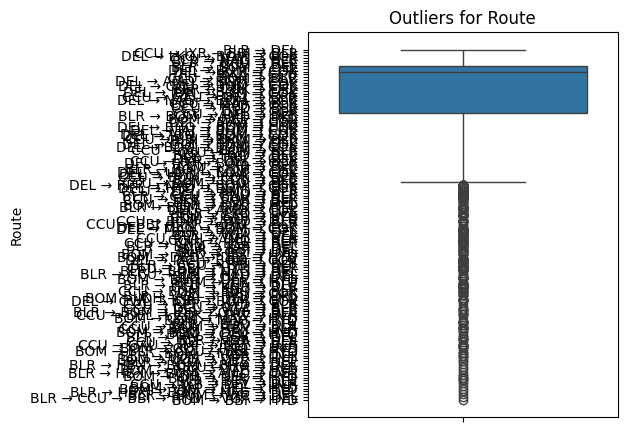

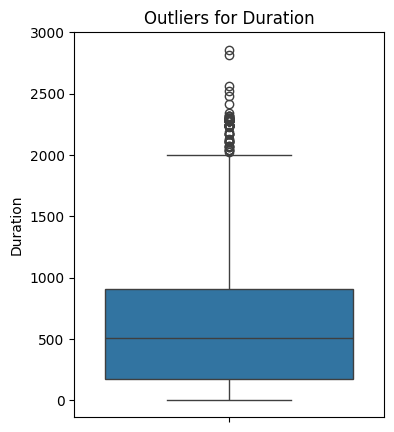

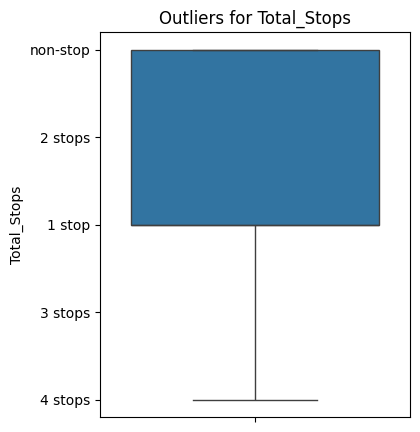

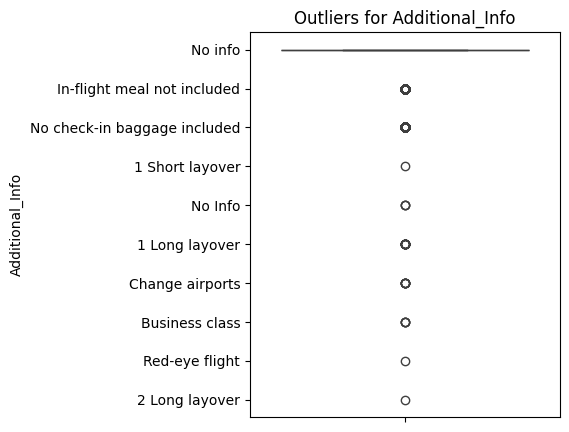

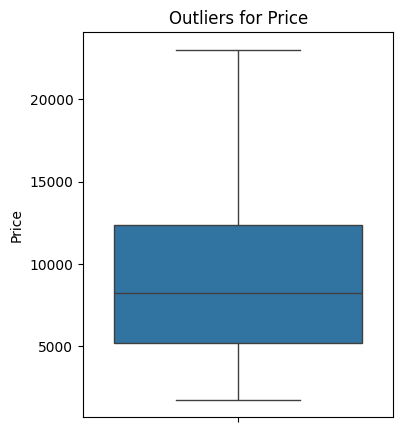

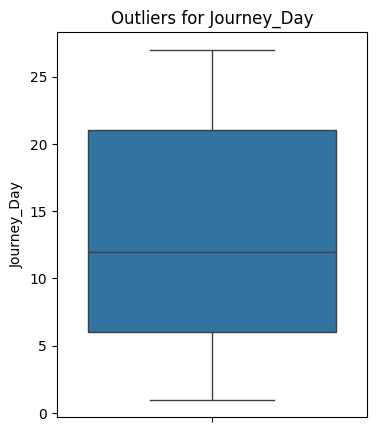

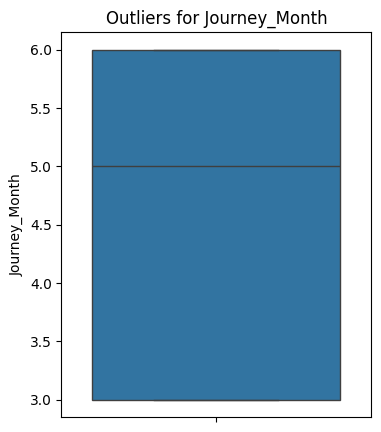

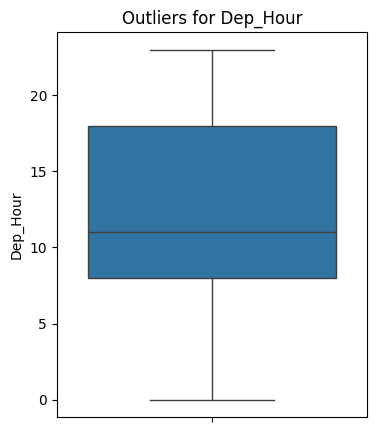

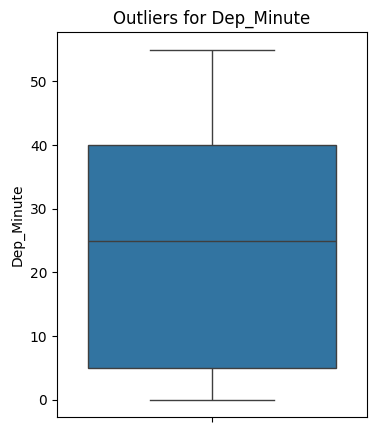

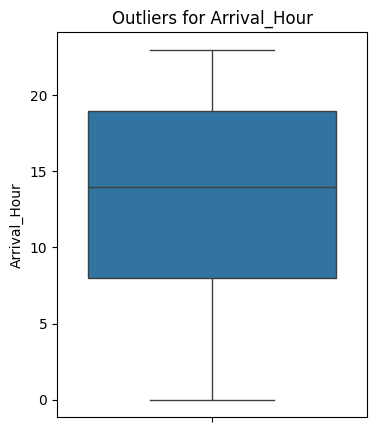

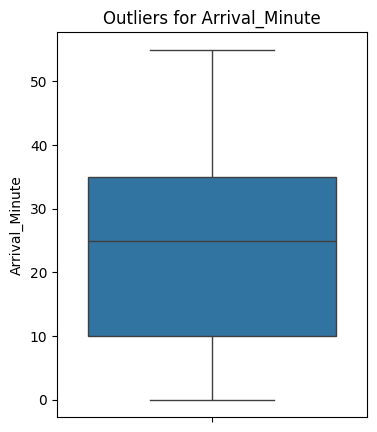

In [43]:
columns = flight_cost.columns

for out_columns in columns:
    plt.figure(figsize=(4,5))

    sns.boxplot(y=flight_cost[out_columns])

    plt.title(f'Outliers for {out_columns}')

    plt.show() 

In [44]:
flight_cost.isnull().sum()

Airline            0
Source             0
Destination        0
Route              0
Duration           0
Total_Stops        0
Additional_Info    0
Price              0
Journey_Day        0
Journey_Month      0
Dep_Hour           0
Dep_Minute         0
Arrival_Hour       0
Arrival_Minute     0
dtype: int64

#### 2) Delete Unwanted Columns

In [46]:
columns = ['Route', 'Additional_Info']

for cols in columns:
    flight_cost.drop(cols, axis=1, inplace=True)

flight_cost.head()

C:\Users\Admin\AppData\Local\Temp\ipykernel_25544\1362965833.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  flight_cost.drop(cols, axis=1, inplace=True)
C:\Users\Admin\AppData\Local\Temp\ipykernel_25544\1362965833.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  flight_cost.drop(cols, axis=1, inplace=True)


,Airline,Source,Destination,Duration,Total_Stops,Price,Journey_Day,Journey_Month,Dep_Hour,Dep_Minute,Arrival_Hour,Arrival_Minute
0,IndiGo,Banglore,New Delhi,170,non-stop,3897.0,24,3,22,20,1,10
1,Air India,Kolkata,Banglore,445,2 stops,7662.0,1,5,5,50,13,15
2,Jet Airways,Delhi,Cochin,1140,2 stops,13882.0,9,6,9,25,4,25
3,IndiGo,Kolkata,Banglore,325,1 stop,6218.0,12,5,18,5,23,30
4,IndiGo,Banglore,New Delhi,285,1 stop,13302.0,1,3,16,50,21,35


#### 2) Apply Encoding for Categorical Columns (One-hot Encoding)

In [47]:
flight_cost.select_dtypes(include='object').columns

Index(['Airline', 'Source', 'Destination', 'Total_Stops'], dtype='object')

In [48]:
flight_cost = pd.get_dummies(
    flight_cost,
    columns=flight_cost.select_dtypes(include='object').columns,
    drop_first=True
)

flight_cost.head() 

,Duration,Price,Journey_Day,Journey_Month,Dep_Hour,Dep_Minute,Arrival_Hour,Arrival_Minute,Airline_Air India,Airline_GoAir,...,Source_Mumbai,Destination_Cochin,Destination_Delhi,Destination_Hyderabad,Destination_Kolkata,Destination_New Delhi,Total_Stops_2 stops,Total_Stops_3 stops,Total_Stops_4 stops,Total_Stops_non-stop
0,170,3897.0,24,3,22,20,1,10,False,False,...,False,False,False,False,False,True,False,False,False,True
1,445,7662.0,1,5,5,50,13,15,True,False,...,False,False,False,False,False,False,True,False,False,False
2,1140,13882.0,9,6,9,25,4,25,False,False,...,False,True,False,False,False,False,True,False,False,False
3,325,6218.0,12,5,18,5,23,30,False,False,...,False,False,False,False,False,False,False,False,False,False
4,285,13302.0,1,3,16,50,21,35,False,False,...,False,False,False,False,False,True,False,False,False,False


### 7) Data Preprocessing

#### 1) Feature Selection

In [49]:
X = flight_cost.drop('Price', axis=1)
y = flight_cost['Price']

#### 2) Train-Test Split

In [52]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [53]:
X_train.shape

(8370, 31)

In [54]:
X_train.head()

,Duration,Journey_Day,Journey_Month,Dep_Hour,Dep_Minute,Arrival_Hour,Arrival_Minute,Airline_Air India,Airline_GoAir,Airline_IndiGo,...,Source_Mumbai,Destination_Cochin,Destination_Delhi,Destination_Hyderabad,Destination_Kolkata,Destination_New Delhi,Total_Stops_2 stops,Total_Stops_3 stops,Total_Stops_4 stops,Total_Stops_non-stop
6615,660,9,3,20,10,7,10,False,False,False,...,False,True,False,False,False,False,False,False,False,False
6729,395,18,5,17,0,23,35,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3475,850,18,5,8,25,22,35,False,False,False,...,False,False,False,False,False,False,False,False,False,False
8977,860,15,5,6,40,21,0,False,False,True,...,False,True,False,False,False,False,False,False,False,False
3494,180,6,5,8,20,11,20,False,False,False,...,False,False,True,False,False,False,False,False,False,True


In [55]:
X_test.shape

(2093, 31)

In [56]:
y_train.head()

6615     8327.0
6729    14151.0
3475    10844.0
8977     7191.0
3494     4544.0
Name: Price, dtype: float64

In [57]:
y_train.shape

(8370,)

#### 3) Feature Scaling

In [59]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [64]:
print("Maximum Values :", X_test.max())
print("Minimum Values :", X_test.min())

Maximum Values : 40.902322672435126
Minimum Values : -2.177590485653298


In [65]:
print("Maximum Values :", X_train.max())
print("Minimum Values :", X_train.min())

Maximum Values : 91.48223871331527
Minimum Values : -2.177590485653298


### 8) Model Buliding

#### Linear Regression

In [71]:
LR = LinearRegression()

LR.fit(X_train, y_train)

y_predict = LR.predict(X_test)

In [72]:
y_predict

array([11421.71719129, 12121.10563079,  4085.92888725, ...,
        6417.26354836,  9540.83669435,  6351.49399993], shape=(2093,))

### 9) Model Evaluation

In [73]:
mae = mean_absolute_error(y_test,y_predict)
mse = mean_squared_error(y_test,y_predict)
r2 = r2_score(y_test,y_predict)

print("Mean Absoulte Error :", mae)
print("Mean Squared Error :", mse)
print("R2 Score :", r2) 

Mean Absoulte Error : 1891.3825656634165
Mean Squared Error : 6477294.787644776
R2 Score : 0.6404330360691435


#### Residual Plot

Text(0, 0.5, 'Residuals')

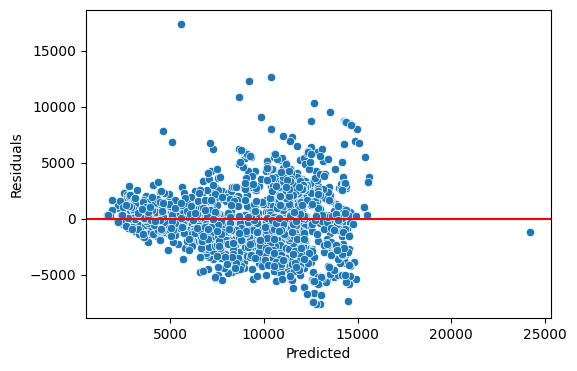

In [74]:
residuals = y_test - y_predict

plt.figure(figsize=(6,4))
sns.scatterplot(x=y_predict,y=residuals)

plt.axhline(0,color='red')
plt.xlabel("Predicted")
plt.ylabel("Residuals") 

#### Actual vs Predicted Plot

Text(0, 0.5, 'Predicted')

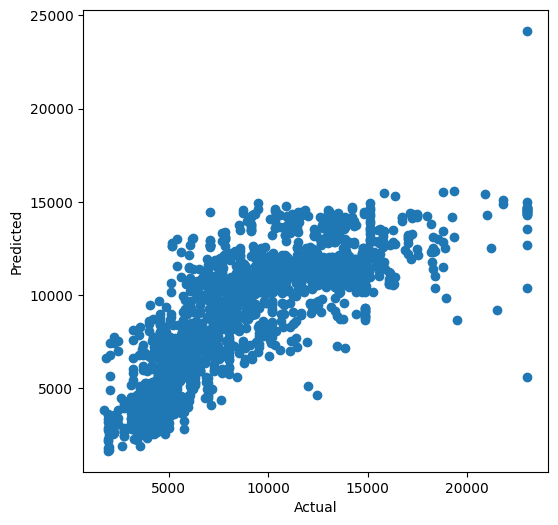

In [75]:
plt.figure(figsize=(6,6))

plt.scatter(y_test,y_predict)

plt.xlabel("Actual")

plt.ylabel("Predicted")